# matfile to pickle

In [1]:
import h5py
import numpy as np
import pandas as pd
import pickle
import os

In [2]:
# Define the path to the directory containing .mat files
mat_directory = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\historical'
pickle_directory = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical'

# Create the pickle directory if it does not exist
os.makedirs(pickle_directory, exist_ok=True)

# Iterate through all .mat files in the directory
for mat_filename in os.listdir(mat_directory):
    if mat_filename.endswith('.mat'):
        mat_path = os.path.join(mat_directory, mat_filename)
        
        # Read the .mat file
        with h5py.File(mat_path, 'r') as file:
#             Extract data
            rain_rate_data = np.array(file['rainRate'])
            rain_total_data = np.array(file['totalRain'])
            lat_data = np.array(file['lat'])
            lon_data = np.array(file['lon'])
            time_data = np.array(file['timesList']).flatten()
            time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
            
#             Print available keys (optional)
            print(f"Keys for {mat_filename}: {list(file.keys())}")
        
        # Store the data in a dictionary
        data_dict = {
            'rainRatePGW': rain_rate_data,
            'totalRainPGW' : rain_total_data,
            'lat': lat_data,
            'lon': lon_data,
            'timesList': time_data,
            'time_vector': time_vector
        }
        
        # Define the path to save the pickle file
        pickle_filename = os.path.splitext(mat_filename)[0] + '.pkl'
        pickle_path = os.path.join(pickle_directory, pickle_filename)
        
        # Save the dictionary as a pickle file
        with open(pickle_path, 'wb') as file:
            pickle.dump(data_dict, file)
        
        print(f'Data from {mat_filename} has been saved to {pickle_path}')


Keys for WRFrain_noPGW_HPE01.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE01.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE01.pkl
Keys for WRFrain_noPGW_HPE02.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE02.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE02.pkl
Keys for WRFrain_noPGW_HPE03.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE03.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE03.pkl
Keys for WRFrain_noPGW_HPE04.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE04.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE04.pkl
Keys for WRFrain_noPGW_HPE05.mat: ['lat', 'lon', 'rainRa

Keys for WRFrain_noPGW_HPE36.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE36.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE36.pkl
Keys for WRFrain_noPGW_HPE37.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE37.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE37.pkl
Keys for WRFrain_noPGW_HPE38.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE38.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE38.pkl
Keys for WRFrain_noPGW_HPE39.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE39.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE39.pkl
Keys for WRFrain_noPGW_HPE40.mat: ['lat', 'lon', 'rainRa

## single plot visualization

Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>


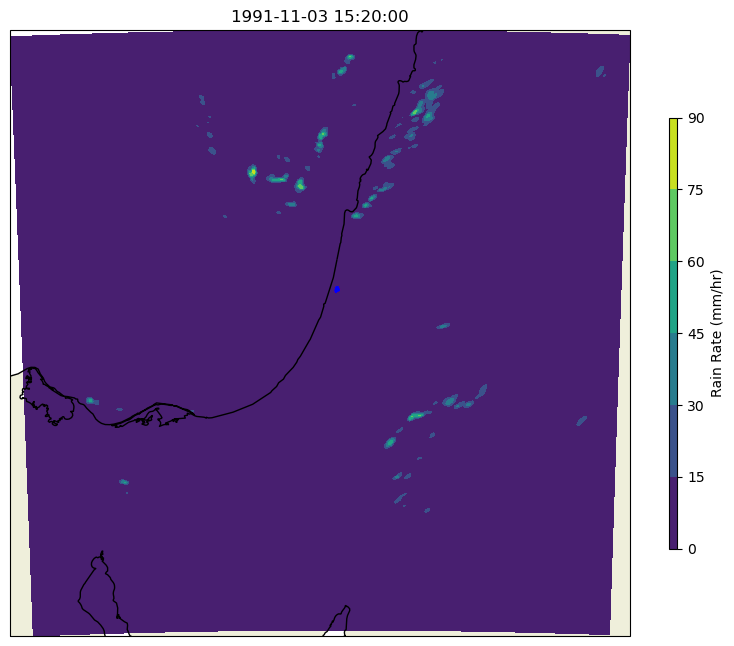

In [165]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\future\WRFrain_PGW_V3_HPE01.mat'
# Define the path to the shapefiles
raanana_shpfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp'
raanana_basins_shapefile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'

# Open the file and load the data
with h5py.File(mat_path, 'r') as file:
    rain_data = np.array(file['rainRatePGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList'])
    time_data = mat_data['timesList'].flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    print("Keys: %s" % file.keys())
# Load the shapefiles using Geopandas and keep only the geometry column
raanana_watershed = gpd.read_file(raanana_shpfile)[['geometry']]
raanana_basins = gpd.read_file(raanana_basins_shapefile)[['geometry']]

# Reproject the shapefiles from ITM to WGS 84
raanana_watershed = raanana_watershed.to_crs(epsg=4326)
raanana_basins = raanana_basins.to_crs(epsg=4326)

time_slice = 200
# Create a plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features to the map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot the rain data
rain_plot = ax.contourf(lon_data, lat_data, rain_data[time_slice,:,:], cmap='viridis', transform=ccrs.PlateCarree())

# Add a color bar
cbar = plt.colorbar(rain_plot, orientation='vertical', pad=0.05, aspect=50, shrink=0.7)
cbar.set_label('Rain Rate (mm/hr)')

# Plot the shapefiles
raanana_watershed.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())
raanana_basins.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Add titles and labels
plt.title(f'{time_vector[time_slice]}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()


# gif visualization

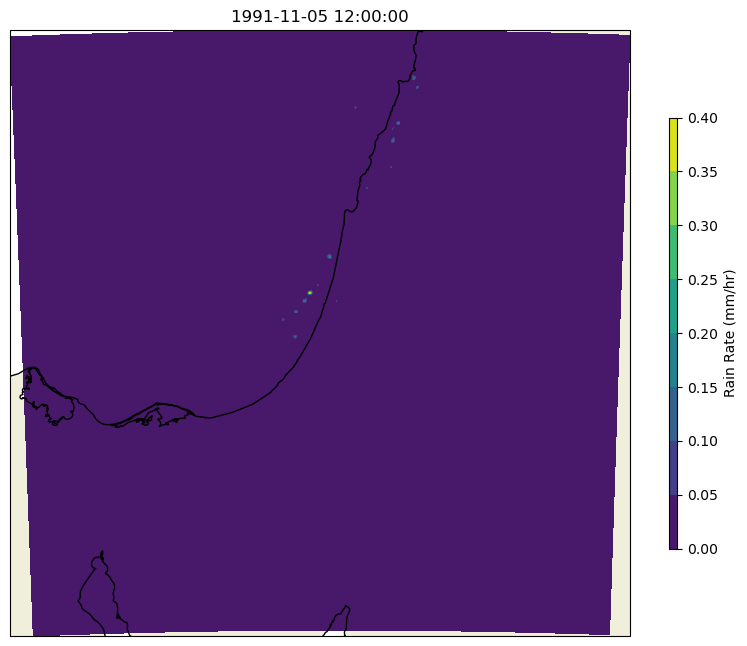

In [170]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.animation as animation

# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\future\WRFrain_PGW_V3_HPE01.mat'
# Define the path to the shapefiles
raanana_shpfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp'
raanana_basins_shapefile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'

# Open the file and load the data
with h5py.File(mat_path, 'r') as file:
    rain_data = np.array(file['rainRatePGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList'])
    time_data = mat_data['timesList'].flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')

# Load the shapefiles using Geopandas and keep only the geometry column
raanana_watershed = gpd.read_file(raanana_shpfile)[['geometry']]
raanana_basins = gpd.read_file(raanana_basins_shapefile)[['geometry']]

# Reproject the shapefiles from ITM to WGS 84
raanana_watershed = raanana_watershed.to_crs(epsg=4326)
raanana_basins = raanana_basins.to_crs(epsg=4326)

# Create a plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features to the map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)

# Initialize the plot with the first frame
rain_plot = ax.contourf(lon_data, lat_data, rain_data[0, :, :], cmap='viridis', transform=ccrs.PlateCarree())
cbar = plt.colorbar(rain_plot, orientation='vertical', pad=0.05, aspect=50, shrink=0.7)
cbar.set_label('Rain Rate (mm/hr)')

# Plot the shapefiles
raanana_watershed.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())
raanana_basins.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())


plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Function to update the plot for each frame
def update(frame):
    global rain_plot
    for c in rain_plot.collections:
        c.remove()
    rain_plot = ax.contourf(lon_data, lat_data, rain_data[frame, :, :], cmap='viridis', transform=ccrs.PlateCarree())
    plt.title(f'{time_vector[frame]}')
# Create the animation for the first 5 frames
ani = animation.FuncAnimation(fig, update, frames=range(rain_data.shape[0]), repeat=True)
# ani = animation.FuncAnimation(fig, update, frames=range(10), repeat=True)

# Save the animation as a GIF using PillowWriter
ani.save('rain_animation_first5.gif', writer='pillow', fps=2)

# Show the plot (optional)
plt.show()
